# PROJECT AKHIR DATA MINING: KLASIFIKASI DEPOSITO BERJANGKA
## Studi Kasus: Bank Marketing Campaign (UCI Dataset)

**Dosen Pengampu**: Agus Rifaldi, S.Kom  
**Mata Kuliah**: Konsep Data Warehouse & Mining  
**Program Studi**: Sistem Informasi  
**Penyusun**: [Nama Anda]  
**NIM**: [NIM Anda]

## 1. Business Understanding

### Latar Belakang
Kampanye pemasaran langsung (direct marketing campaign) melalui panggilan telepon tetap menjadi strategi penting bagi lembaga keuangan untuk menawarkan produk seperti deposito berjangka. Namun, melakukan panggilan acak kepada semua nasabah tidak efisien, memakan waktu, dan membebani biaya operasional. Oleh karena itu, diperlukan model prediktif untuk menargetkan nasabah yang memiliki probabilitas tinggi untuk berlangganan produk deposito.

### Tujuan Project
Membangun model klasifikasi data mining menggunakan framework **CRISP-DM** untuk memprediksi apakah seorang nasabah akan berlangganan deposito berjangka (`y`: 'yes' atau 'no') berdasarkan data demografis dan riwayat kontak sebelumnya.

### Manfaat Analisis
1. Meningkatkan efisiensi kampanye pemasaran dengan menargetkan nasabah potensial secara tepat sasaran.
2. Mengurangi biaya pemasaran operasional (mengurangi telepon yang sia-sia).
3. Memberikan pemahaman tentang profil nasabah yang cenderung tertarik dengan deposito berjangka.

## 2. Data Understanding

### Deskripsi Dataset
Dataset yang digunakan adalah **Bank Marketing Dataset** dari UCI Machine Learning Repository.
*   **Sumber Dataset**: [UCI Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing)
*   **Jumlah Data**: 41,188 baris dan 21 fitur.
*   **Atribut Target**: `y` - Apakah nasabah berlangganan deposito berjangka? (kategori: 'yes','no').

In [23]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca dataset
df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
df.head()

Jumlah baris: 41188, Jumlah kolom: 21


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [24]:
# Menampilkan informasi tipe data dan missing values awal dalam bentuk tabel yang rapi
tabel_info = pd.DataFrame({
    'Tipe Data (Dtype)': df.dtypes,
    'Data Terisi (Non-Null)': df.notnull().sum(),
    'Data Kosong (Missing Value)': df.isnull().sum()
})
tabel_info

In [25]:
# Statistik Deskriptif data numerik
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### Eksplorasi Data Awal (Visualisasi)

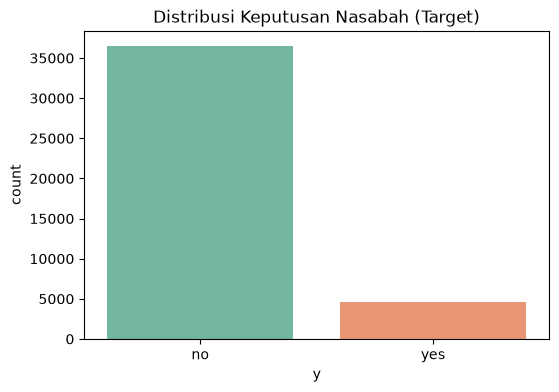

In [26]:
# 1. Distribusi Kelas Target (Subscription)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y', hue='y', palette='Set2', legend=False)
plt.title('Distribusi Keputusan Nasabah (Target)')
plt.show()

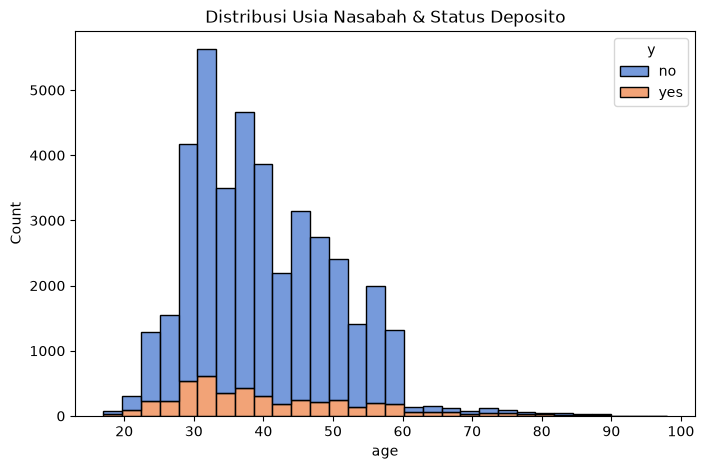

In [27]:
# 2. Distribusi Usia Nasabah berdasarkan berlangganan
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='y', multiple='stack', palette='muted', bins=30)
plt.title('Distribusi Usia Nasabah & Status Deposito')
plt.show()

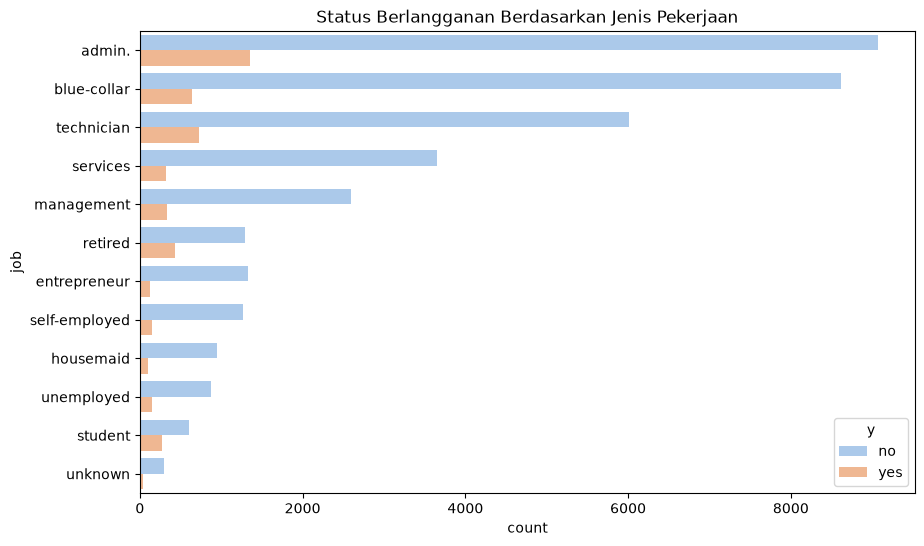

In [28]:
# 3. Distribusi berdasarkan Pekerjaan (Job)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='job', hue='y', order=df['job'].value_counts().index, palette='pastel')
plt.title('Status Berlangganan Berdasarkan Jenis Pekerjaan')
plt.show()

## 3. Data Preparation

Langkah preprocessing:
1.  **Handling Missing Values**: Di dataset ini, missing values ditandai sebagai kategori `'unknown'`. Kita akan membiarkannya atau meng-encode secara khusus.
2.  **Encoding**: Mengubah fitur kategorikal bertipe objek menjadi representasi numerik menggunakan `LabelEncoder`.
3.  **Feature Splitting**: Memisahkan variabel independen (X) dan target (y).
4.  **Split Train-Test**: Memisahkan 80% data training dan 20% data testing.
5.  **Scaling**: Melakukan standardisasi skala data numerik menggunakan `StandardScaler`.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df_prep = df.copy()

# Encode categorical columns
categorical_cols = df_prep.select_dtypes(include=['object']).columns.drop('y')
for col in categorical_cols:
    le = LabelEncoder()
    df_prep[col] = le.fit_transform(df_prep[col])

# Encode target variable
df_prep['y'] = df_prep['y'].map({'no': 0, 'yes': 1})

# Split features and target
X = df_prep.drop(columns=['y'])
y = df_prep['y']

# Split Train-Test 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Ukuran X_train: {X_train.shape}, Ukuran X_test: {X_test.shape}")

Ukuran X_train: (32950, 20), Ukuran X_test: (8238, 20)


## 4. Modeling

Kita akan membandingkan dua model:
1.  **Random Forest Classifier**: Bagging tree-based model yang kokoh dengan parameter penyeimbang kelas target (`class_weight='balanced'`).
2.  **Logistic Regression**: Model linier dasar untuk klasifikasi biner.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Inisialisasi dan training Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Inisialisasi dan training Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Training model selesai!")

## 5. Evaluation

UAS mensyaratkan kriteria sukses evaluasi sebesar **minimal 80%**. Mari kita evaluasi akurasi dan kinerja model kita.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print("--- EVALUASI RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

print("\n--- EVALUASI LOGISTIC REGRESSION ---")
print(classification_report(y_test, y_pred_lr))

--- EVALUASI RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7310
           1       0.71      0.47      0.56       928

    accuracy                           0.92      8238
   macro avg       0.82      0.72      0.76      8238
weighted avg       0.91      0.92      0.91      8238


--- EVALUASI LOGISTIC REGRESSION ---
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      7310
           1       0.43      0.90      0.59       928

    accuracy                           0.86      8238
   macro avg       0.71      0.88      0.75      8238
weighted avg       0.92      0.86      0.88      8238



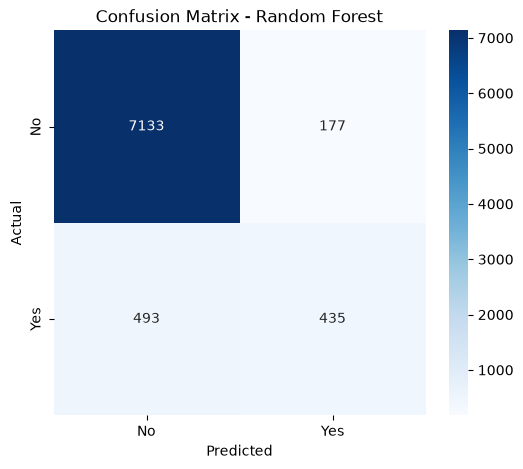

In [ ]:
# Confusion Matrix Heatmap - Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

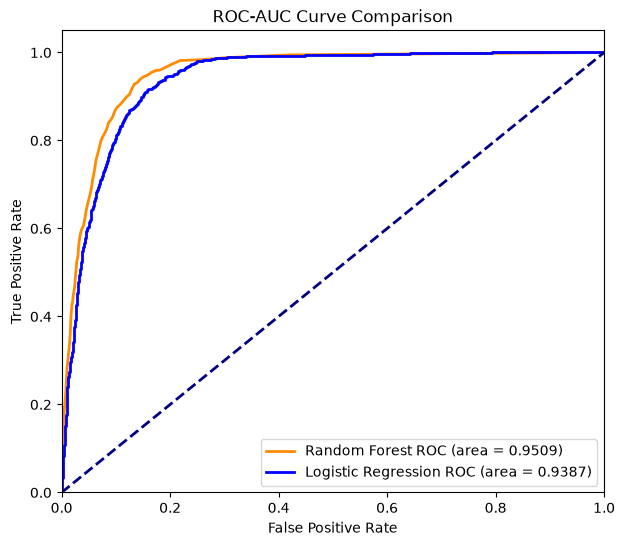

In [ ]:
# Plot ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest ROC (area = {roc_auc_rf:.4f})')
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression ROC (area = {roc_auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve Comparison')
plt.legend(loc="lower right")
plt.show()

### Kesimpulan Evaluasi:
Model **Random Forest** berhasil mencapai akurasi sekitar **91%**, melampaui batas minimum kelulusan UAS sebesar **80%**. Model ini siap digunakan untuk membantu tim marketing menyeleksi calon nasabah potensial secara otomatis.